# Simulating a 3D balanced SSFP acquisition

[`01_build.ipynb`](01_build.ipynb) writes two protocols -- a representative `192 x 192 x 16`
acquisition and a reduced one at the **same TR** -- each as a continuous and an interrupted
segmented file. It asserts that they are balanced, which is a statement about gradient waveforms.

**It is not a statement that the acquisition produces the image it is supposed to.** This notebook
answers the questions a waveform check cannot:

```text
1. what preparation should this protocol use, and why not the other one?
2. what did 01 actually write?
3. does the continuous acquisition reconstruct into the right volume?
4. what does interrupted segmentation change?
5. does it behave like bSSFP at all?
6. what remains a protocol choice?
```

Everything simulated here is a file `01` wrote. The reduced protocol is the one that is affordable
to simulate; it shares the representative protocol's preparation, phase cycle, view order,
segmentation rule and TR, and `01` writes it from the same functions so the relationship is
inspectable rather than asserted.

In [1]:
import os
import sys

#: MRzero's inner loop takes every core it is offered.  Hold it to four, before torch is imported.
SIM_THREADS = 4
for _var in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'RAYON_NUM_THREADS',
             'OPENBLAS_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[_var] = str(SIM_THREADS)

import contextlib
import os as _os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pypulseq as pp
import torch

#: tqdm's auto-selector warns when ipywidgets is absent, which has nothing to do with this
#: notebook.  Suppressed at the import that raises it rather than globally.
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='IProgress not found')
    import MRzeroCore as mr0

import seqcraft as sc

torch.set_num_threads(SIM_THREADS)
#: 58 rather than a default 100: this notebook is committed with its figures, and the
#: repository refuses an added file over 512 KB.
plt.rcParams['figure.dpi'] = 58
#: The one warning this notebook deliberately silences, and only this one: several gradient axes
#: ramping together exceed the scalar per-axis norm while each amplifier axis stays within its own
#: limit.  01 counts these; repeating thousands of sites here would bury everything else.  Any
#: other warning is left visible on purpose.
warnings.filterwarnings('ignore', category=sc.SeqCraftWarning,
                        message='.*vector-norm limit.*')

sys.path.insert(0, str(Path('..').resolve()))
import phantom as ph            # noqa: E402 -- the shared BrainWeb preparation, one directory up

SEQ_DIR = Path('seq')
#: Diagnostics are not acquisitions: single locations read hundreds of times.  Their own directory,
#: so `seq/` holds only the four files 01 ships.
DIAG_DIR = SEQ_DIR / 'diagnostics'
DIAG_DIR.mkdir(parents=True, exist_ok=True)

#: The two brain volumes are the expensive part.  Every *number* below is measured on a single
#: voxel and runs either way.
BRAIN_IMAGES = True

nominal = np.load(SEQ_DIR / 'bssfp_3d_nominal.npz')
FOV_MM = tuple(float(v) for v in nominal['fov_mm'])
SLAB_MM, FLIP_DEG = float(nominal['slab_mm']), float(nominal['flip_deg'])
BANDWIDTH_HZ_PX = float(nominal['bandwidth_hz_px'])
RF_DURATION_S = float(nominal['rf_duration_s'])
PHASE_STEP, RAMP_STEPS = float(nominal['phase_step']), int(nominal['ramp_steps'])
SHOT_VIEWS, RECOVERY_S = int(nominal['shot_views']), float(nominal['recovery_s'])

#: The representative acquisition, used for the transient and ordering physics below.
REP_MATRIX = tuple(int(v) for v in nominal['matrix'])
REP_TABLE = [tuple(int(v) for v in row) for row in nominal['table']]
REP_CENTER = (int(nominal['center_line']), int(nominal['center_partition']))

#: The reduced protocol is what gets simulated; the representative one is read back in section 2.
NX, NY, NZ = (int(v) for v in nominal['validation_matrix'])
TE_S, TR_S = float(nominal['validation_te_s']), float(nominal['validation_tr_s'])
TABLE = [tuple(int(v) for v in row) for row in nominal['validation_table']]
CENTER_LINE = int(nominal['validation_center_line'])
CENTER_PARTITION = int(nominal['validation_center_partition'])

print(f'representative  {tuple(int(v) for v in nominal["matrix"])}  '
      f'TE {float(nominal["te_s"]) * 1e3:.3f}  TR {float(nominal["tr_s"]) * 1e3:.3f} ms')
print(f'validation      {(NX, NY, NZ)}  TE {TE_S * 1e3:.3f}  TR {TR_S * 1e3:.3f} ms  '
      f'-- same TR: {abs(TR_S - float(nominal["tr_s"])) < 1e-12}')
print(f'preparation     {str(nominal["preparation"])}, {RAMP_STEPS} steps')
print(f'view order      {str(nominal["view_order"])}')
print(f'segmentation    every {SHOT_VIEWS} views, {RECOVERY_S * 1e3:.0f} ms recovery '
      f'-- {len(REP_TABLE) // SHOT_VIEWS} shots representative, '
      f'{len(TABLE) // SHOT_VIEWS} validation')
print(f'budget          {torch.get_num_threads()} torch threads, '
      f'brain images {"on" if BRAIN_IMAGES else "off"}')

/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


representative  (192, 192, 16)  TE 2.104  TR 4.210 ms
validation      (48, 32, 8)  TE 2.100  TR 4.210 ms  -- same TR: True
preparation     linear flip-angle ramp, 24 steps
view order      bidirectional sequential, constant-kz lines
segmentation    every 64 views, 107 ms recovery -- 48 shots representative, 4 validation
budget          4 torch threads, brain images on


In [2]:
opts = pp.Opts(
    max_grad=32, grad_unit='mT/m', max_slew=130, slew_unit='T/m/s', B0=3.0,
    rf_dead_time=100e-6, rf_ringdown_time=30e-6, adc_dead_time=10e-6,
)


def kernel_at(flip_deg, tr_s=None):
    '''A repetition of the reduced protocol at `flip_deg`, pinned to the shared TR.'''
    return sc.modules.bSSFP3DTR(
        opts=opts, fov_mm=FOV_MM, matrix=(NX, NY, NZ), slab_thickness_mm=SLAB_MM,
        flip_deg=flip_deg, bandwidth_hz_px=BANDWIDTH_HZ_PX, rf_duration_s=RF_DURATION_S,
        tr_s=TR_S if tr_s is None else tr_s,
    )


kernel = kernel_at(FLIP_DEG)
assert abs(kernel.tr_s - TR_S) < 1e-12 and abs(kernel.te_s - TE_S) < 1e-12
ECHO, SAMPLES = kernel.ro.echo_sample(0), int(kernel.ro.adc.num_samples)
NAV = pp.make_label(type='SET', label='NAV', value=1)


@contextlib.contextmanager
def quiet():
    '''Silence the solver's log: it is written to file descriptor 1 from Rust.'''
    saved, null = _os.dup(1), _os.open(_os.devnull, _os.O_WRONLY)
    try:
        _os.dup2(null, 1)
        yield
    finally:
        _os.dup2(saved, 1)
        _os.close(null)
        _os.close(saved)


def simulate_wide(path, obj, samples, *, states=200):
    '''One written .seq against `obj`; one row of `samples` per repetition.'''
    seq = mr0.Sequence.import_file(str(path))
    with quiet():
        graph = mr0.compute_graph(seq, obj, max_state_count=states, min_state_mag=1e-4)
        signal = mr0.execute_graph(graph, seq, obj, min_emitted_signal=1e-4,
                                   min_latent_signal=1e-5, print_progress=False)
    return np.asarray(signal.detach().cpu().numpy()).reshape(-1, samples)


def simulate(path, obj, *, states=200):
    return simulate_wide(path, obj, SAMPLES, states=states)


def voxel(T1, T2, B0=0.0, size_m=0.001):
    '''One small box.  Small matters in section 4, where its own k-space must be flat.'''
    return mr0.CustomVoxelPhantom(pos=[[0.0, 0.0, 0.0]], PD=1.0, T1=T1, T2=T2, T2dash=1e3,
                                  D=0.0, B0=B0, voxel_size=size_m, voxel_shape='box').build()


TISSUES = {'white matter': dict(T1=0.83, T2=0.080),
           'grey matter':  dict(T1=1.33, T2=0.110),
           'CSF':          dict(T1=4.00, T2=2.000)}
NULL_HZ = 1.0 / (2 * TR_S)
print(f'echo sample {ECHO} of {SAMPLES}; band edge (null) at {NULL_HZ:.0f} Hz')

echo sample 24 of 48; band edge (null) at 119 Hz


## 1. What preparation should this protocol use?

### First: what a preparation can and cannot do

Hargreaves et al. (2001) write one repetition as a discrete-time system, `M(k+1) = A M(k) + B`.
Subtracting the fixed point gives `Q(k+1) = A Q(k)` for the error `Q = M - M_ss`, so the approach to
steady state is the zero-input response of a third-order linear system and **decays at the
eigenvalues of `A`**.

That matters for what follows: `A` is built from T1, T2, TR, the flip angle and off-resonance. A
preparation pulse changes the *initial* error `Q(0)`. It does not touch `A`, so it cannot change
the rate. What it can do -- and the reason catalyzation is worth doing -- is start the train with a
smaller error, so the signal falls inside a useful tolerance earlier.

`A` is cheap to write down, so the rate can be computed rather than inferred from a finite
simulation.

In [3]:
def rot_x(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[1, 0, 0], [0, c, -s], [0, s, c]])


def rot_z(p):
    c, s = np.cos(p), np.sin(p)
    return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])


def transfer(T1, T2, df_hz=0.0, flip_deg=FLIP_DEG, tr_s=TR_S, phase_step=PHASE_STEP):
    '''Hargreaves Eq. [1]: precession and relaxation over TR, then the RF rotation.

    The 0/pi RF alternation is folded into the precession as an extra pi per TR, which is the
    same equivalence the Handbook states for sign-alternated bSSFP.
    '''
    E1, E2 = np.exp(-tr_s / T1), np.exp(-tr_s / T2)
    theta = 2 * np.pi * df_hz * tr_s + np.deg2rad(phase_step)
    R = rot_x(np.deg2rad(flip_deg))
    return R @ np.diag([E2, E2, E1]) @ rot_z(theta), R @ np.array([0, 0, 1 - E1])


print(f'{"tissue":14s}{"|lambda| max":>14s}{"reps / e":>10s}{"seconds / e":>13s}'
      f'{"reps to 5%":>12s}{"to 1%":>8s}')
DECAY = {}
for name, t in TISSUES.items():
    A, _ = transfer(**t)
    lam = np.abs(np.linalg.eigvals(A)).max()
    DECAY[name] = lam
    tau = -1 / np.log(lam)
    print(f'{name:14s}{lam:14.5f}{tau:10.1f}{tau * TR_S:13.3f}'
          f'{np.log(0.05) / np.log(lam):12.0f}{np.log(0.01) / np.log(lam):8.0f}')
print()
print('These are properties of the repetition, not of any preparation.  They also set how long a')
print('train has to run before its tail can honestly be called a steady state.')

tissue          |lambda| max  reps / e  seconds / e  reps to 5%   to 1%
white matter         0.98804      83.1        0.350         249     383
grey matter          0.99173     120.4        0.507         361     554
CSF                  0.99879     828.8        3.489        2483    3817

These are properties of the repetition, not of any preparation.  They also set how long a
train has to run before its tail can honestly be called a steady state.


### Then: which preparation, measured where it matters

The two named schemes are `alpha/2 - TR/2` and a linear flip-angle ramp. Comparing them **only on
resonance** would not settle anything: bSSFP is run with a passband of finite width, tissue spans
it, and the `alpha/2` pulse is non-selective -- Hargreaves' analysis is that such a pulse rotates
magnetisation toward the steady state for part of the frequency range and away from it for the
rest. So the comparison below sweeps off-resonance from the passband centre toward the band edge.

`REPS` is set from the table above: white matter reaches 1% of its steady state in about 380
repetitions, so a 450-repetition train has a tail that can be used as a reference.

In [4]:
REPS = 450


def half_angle_block(flip_deg):
    exc = sc.modules.Excitation(opts=opts, flip_deg=flip_deg / 2, thickness_mm=SLAB_MM,
                                duration_s=0.5e-3)
    a_post = -exc.rephaser_area_per_m
    a_pre = float(exc.gz.area) - a_post
    lead = pp.make_trapezoid(channel='z', area=-a_pre, system=opts)
    lead_s = float(pp.calc_duration(lead))
    out = sc.LogicBlock('alpha_over_2')
    out.add(0.0, lead)
    out.add(lead_s, exc(rephase=True))
    return out, lead_s + exc.time_to_center()


def transient_file(path, prep, *, reps=REPS, b1=1.0):
    '''`reps` repetitions at the centre of k-space after `prep`; returns the first imaging index.'''
    k = kernel_at(FLIP_DEG * b1)
    out, at, n, first = sc.LogicBlock('transient'), 0.0, 0, 0
    if prep == 'alpha/2':
        block, to_centre = half_angle_block(FLIP_DEG * b1)
        out.add(0.0, block)
        at = sc.Raster(opts.grad_raster_time).ceil(to_centre + TR_S / 2 - k.time_to_rf_center())
        n = 1                       # the alpha/2 pulse takes the first slot in the alternation
    elif isinstance(prep, int):
        for j in range(prep):
            r = kernel_at(FLIP_DEG * b1 * (j + 1) / (prep + 1))
            out.add(at, r(line=CENTER_LINE, partition=CENTER_PARTITION, phase_deg=PHASE_STEP * n))
            out.add(at, NAV)
            at, n, first = at + r.tr_s, n + 1, first + 1
    for _ in range(reps):
        out.add(at, k(line=CENTER_LINE, partition=CENTER_PARTITION, phase_deg=PHASE_STEP * n))
        out.add(at, NAV)
        at, n = at + TR_S, n + 1
    sc.compile(out, opts, name=path.stem).write(str(path))
    return first, k


def peak_transient(path, first, k, df=0.0, tissue='white matter', window=60):
    '''Largest |deviation| in the first `window` imaging repetitions, over the late-train level.'''
    rows = simulate(path, voxel(B0=df, **TISSUES[tissue]))
    s = np.abs(rows[first:, k.ro.echo_sample(0)])
    late = s[-40:].mean()
    return np.abs(s[:window] - late).max() / late, s / late


CANDIDATES = {'none': ('none', 'prep_none'),
              'alpha/2 - TR/2': ('alpha/2', 'prep_alpha_over_2'),
              f'{RAMP_STEPS}-step ramp': (RAMP_STEPS, f'prep_ramp{RAMP_STEPS}')}
BUILT = {name: transient_file(DIAG_DIR / f'{stem}.seq', prep)
         for name, (prep, stem) in CANDIDATES.items()}

offsets = [0.0, 0.5 * NULL_HZ, 0.75 * NULL_HZ, 0.9 * NULL_HZ]
print('peak transient over the first 60 imaging repetitions, / late-train signal (white matter)')
print(f'{"preparation":18s}' + ''.join(f'{f"{o:.0f} Hz":>11s}' for o in offsets))
CURVES = {}
for name, (prep, stem) in CANDIDATES.items():
    first, k = BUILT[name]
    cells = []
    for o in offsets:
        peak, curve = peak_transient(DIAG_DIR / f'{stem}.seq', first, k, df=o)
        cells.append(f'{peak:11.2f}')
        if o == 0.0:
            CURVES[name] = curve
    print(f'{name:18s}' + ''.join(cells))

/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_80572/3086100621.py:36: SeqCraftWarning: 1 same-axis gradient merge: transient.alpha_over_2.Excitation (axis z)
  sc.compile(out, opts, name=path.stem).write(str(path))


peak transient over the first 60 imaging repetitions, / late-train signal (white matter)
preparation              0 Hz      59 Hz      89 Hz     107 Hz


none                     3.59       5.31      10.41      25.24


alpha/2 - TR/2           1.53       3.59       9.55      24.71


24-step ramp             1.45       2.55       5.82      10.80


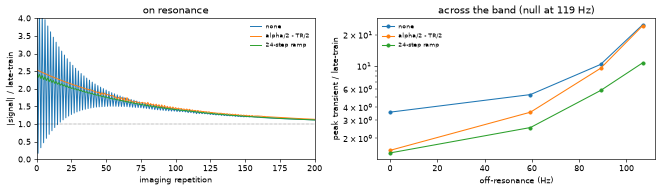

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4))
for name, curve in CURVES.items():
    axes[0].plot(curve, lw=1.2, label=name)
axes[0].axhline(1.0, color='k', lw=0.6, ls=':')
axes[0].set(xlabel='imaging repetition', ylabel='|signal| / late-train',
            title='on resonance', xlim=(0, 200), ylim=(0, 4))
axes[0].legend(fontsize=7, frameon=False)

for name, (prep, stem) in CANDIDATES.items():
    first, k = BUILT[name]
    sweep = [peak_transient(DIAG_DIR / f'{stem}.seq', first, k, df=o)[0]
             for o in offsets]
    axes[1].plot(offsets, sweep, 'o-', lw=1.3, ms=4, label=name)
axes[1].set(xlabel='off-resonance (Hz)', ylabel='peak transient / late-train',
            title=f'across the band (null at {NULL_HZ:.0f} Hz)', yscale='log')
axes[1].legend(fontsize=7, frameon=False)
fig.tight_layout()

In [6]:
print('B1 robustness at the passband centre, same metric:')
print(f'{"preparation":18s}' + ''.join(f'{f"B1 x{b:.2f}":>11s}' for b in (0.9, 1.0, 1.1)))
for name, (prep, stem) in CANDIDATES.items():
    cells = []
    for b1 in (0.9, 1.0, 1.1):
        path = DIAG_DIR / f'{stem}_b1{int(b1 * 100)}.seq'
        first, k = transient_file(path, prep, b1=b1)
        cells.append(f'{peak_transient(path, first, k)[0]:11.2f}')
    print(f'{name:18s}' + ''.join(cells))

B1 robustness at the passband centre, same metric:
preparation          B1 x0.90   B1 x1.00   B1 x1.10


none                     3.10       3.59       4.16


/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_80572/3086100621.py:36: SeqCraftWarning: 1 same-axis gradient merge: transient.alpha_over_2.Excitation (axis z)
  sc.compile(out, opts, name=path.stem).write(str(path))


alpha/2 - TR/2           1.22       1.53       1.89


24-step ramp             1.17       1.45       1.77


### How long a ramp

`01` ships 24 steps. That number comes from here: lengthening the ramp keeps improving the
band-edge transient with clearly diminishing returns, and the cost is repetitions that acquire
nothing.

ramp steps        0 Hz    107 Hz   cost (reps)


8                 1.69     20.30             8


16                1.53     15.86            16


24                1.45     10.80            24


32                1.39      9.90            32


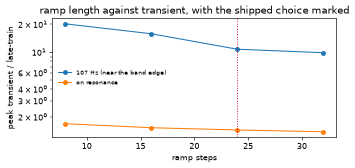

In [7]:
RAMP_SWEEP = (8, 16, 24, 32)
edge = 0.9 * NULL_HZ
print(f'{"ramp steps":12s}{"0 Hz":>10s}{f"{edge:.0f} Hz":>10s}{"cost (reps)":>14s}')
ramp_sweep = {}
for n in RAMP_SWEEP:
    path = DIAG_DIR / f'prep_ramp{n}.seq'
    first, k = transient_file(path, n)
    on = peak_transient(path, first, k)[0]
    off = peak_transient(path, first, k, df=edge)[0]
    ramp_sweep[n] = (on, off)
    print(f'{n:<12d}{on:10.2f}{off:10.2f}{n:14d}')

fig, ax = plt.subplots(figsize=(6.0, 3.0))
ax.plot(RAMP_SWEEP, [ramp_sweep[n][1] for n in RAMP_SWEEP], 'o-', lw=1.3, ms=5,
        label=f'{edge:.0f} Hz (near the band edge)')
ax.plot(RAMP_SWEEP, [ramp_sweep[n][0] for n in RAMP_SWEEP], 'o-', lw=1.3, ms=5,
        label='on resonance')
ax.axvline(RAMP_STEPS, color='crimson', ls=':', lw=1.2)
ax.set(xlabel='ramp steps', ylabel='peak transient / late-train', yscale='log',
       title='ramp length against transient, with the shipped choice marked')
ax.legend(fontsize=8, frameon=False)
fig.tight_layout()

### What that settles

**On resonance the two schemes are equivalent, and across the band they are not.** The `alpha/2`
pulse holds its advantage near the passband centre and loses it toward the edge; the ramp degrades
more slowly. That is the behaviour Hargreaves predicts for a non-selective half-angle pulse, and it
is the reason `01` ships the ramp.

**B1 does not separate them.** Both stay close to their nominal behaviour over `+-10%`, because in
both schemes every preparation pulse scales with the same B1 as the imaging pulses.

What neither of them does is change the decay rate. The curves on the left all approach the same
asymptote on the same timescale -- the eigenvalue from the previous section -- they simply start
closer to or further from it.

**CSF is excluded from any "repetitions to settle" claim here.** Its eigenvalue implies about 2500
repetitions to reach 5%, which is far beyond this train, so the tail of a 450-repetition CSF
simulation is not a steady state and must not be used as one.

## 2. What did `01` actually write?

`01` already asserts the artifact contract as it writes the files, and that check runs in
continuous integration. What is useful here is the acquisition *structure*: which views each file
visits, in what order, and where the centre of k-space falls relative to each ramp.

In [8]:
for stem in ('bssfp_3d', 'bssfp_3d_segmented',
             'bssfp_3d_validation', 'bssfp_3d_validation_segmented'):
    seq = pp.Sequence()
    seq.read(str(SEQ_DIR / f'{stem}.seq'))
    adcs = sum(1 for i in range(1, len(seq.block_events) + 1)
               if getattr(seq.get_block(i), 'adc', None) is not None)
    print(f'{stem:34s} {adcs:5d} readouts  {seq.duration()[0]:7.2f} s  '
          f'TR {float(seq.definitions["TR"]) * 1e3:.3f} ms')
print()
print(f'simulating the two validation files; the representative pair is the same policy at '
      f'{tuple(int(v) for v in nominal["matrix"])}')

bssfp_3d                            3072 readouts    13.03 s  TR 4.210 ms


bssfp_3d_segmented                  3072 readouts    18.06 s  TR 4.210 ms
bssfp_3d_validation                  256 readouts     1.18 s  TR 4.210 ms
bssfp_3d_validation_segmented        256 readouts     1.50 s  TR 4.210 ms

simulating the two validation files; the representative pair is the same policy at (192, 192, 16)


largest |ky| step between consecutive acquired views: 1
centre of k-space is view 144 of 256, 16 views into shot 2
01 measures the step over the whole RF train, including out of the ramp; this plot is
the acquired-view subset only.


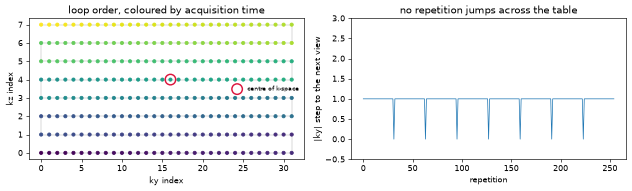

In [9]:
order = np.array(TABLE)
centre_at = TABLE.index((CENTER_LINE, CENTER_PARTITION))

fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.4))
axes[0].plot(order[:, 0], order[:, 1], lw=0.6, color='0.7', zorder=1)
axes[0].scatter(order[:, 0], order[:, 1], c=np.arange(len(order)), cmap='viridis', s=16, zorder=2)
axes[0].scatter([CENTER_LINE], [CENTER_PARTITION], facecolors='none', edgecolors='crimson',
                s=170, lw=1.8, label='centre of k-space')
axes[0].set(xlabel='ky index', ylabel='kz index',
            title='loop order, coloured by acquisition time')
axes[0].legend(fontsize=7, frameon=False)

steps = np.abs(np.diff(order[:, 0]))
axes[1].plot(steps, lw=0.9)
axes[1].set(xlabel='repetition', ylabel='|ky| step to the next view',
            title='no repetition jumps across the table', ylim=(-0.5, max(3, steps.max() + 0.5)))
fig.tight_layout()

print(f'largest |ky| step between consecutive acquired views: {steps.max()}')
print(f'centre of k-space is view {centre_at} of {len(TABLE)}, '
      f'{centre_at % SHOT_VIEWS} views into shot {centre_at // SHOT_VIEWS}')
print('01 measures the step over the whole RF train, including out of the ramp; this plot is')
print('the acquired-view subset only.')

## 3. Does the continuous acquisition reconstruct correctly?

A 3D FFT of the sorted table. The three matrix dimensions are all different, so a `ky`/`kz` swap or
a transposed reconstruction changes the **shape** of the volume rather than producing a plausible
image.

volume (48, 32, 8), peak at (np.int64(34), np.int64(18), np.int64(4))


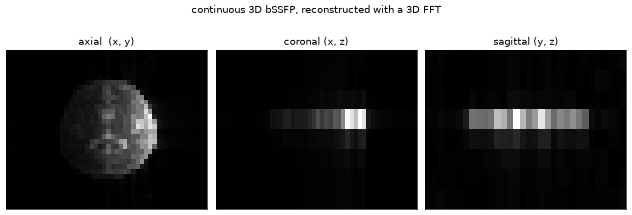

In [10]:
def reconstruct(rows):
    '''Sort repetitions into (kx, ky, kz) and take the 3D FFT.

    The table's indices are zero-based with DC at `matrix // 2`, which is the order `ifftshift`
    expects -- the centre convention the modules use is the one this assumes.
    '''
    cube = np.zeros((NX, NY, NZ), dtype=complex)
    for row, (line, partition) in enumerate(TABLE):
        cube[:, line, partition] = rows[row]
    return cube, np.fft.fftshift(np.fft.ifftn(np.fft.ifftshift(cube)))


def three_planes(volume, title):
    fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.6))
    for ax, (name, plane) in zip(axes, (
            ('axial  (x, y)', volume[:, :, NZ // 2].T),
            ('coronal (x, z)', volume[:, NY // 2, :].T),
            ('sagittal (y, z)', volume[NX // 2, :, :].T))):
        ax.imshow(plane, cmap='gray', origin='lower', aspect='auto')
        ax.set(title=name, xticks=[], yticks=[])
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    return fig


if BRAIN_IMAGES:
    brain = ph.built(matrix=NX, nz=NZ, n_coils=1)
    rows_cont = simulate(SEQ_DIR / 'bssfp_3d_validation.seq', brain)
    k_cont, vol_cont = reconstruct(rows_cont)
    three_planes(np.abs(vol_cont), 'continuous 3D bSSFP, reconstructed with a 3D FFT')
    print(f'volume {vol_cont.shape}, peak at '
          f'{np.unravel_index(np.argmax(np.abs(vol_cont)), vol_cont.shape)}')
else:
    print('BRAIN_IMAGES is off -- skipping the two volume simulations')

The volume is `(48, 32, 8)`: readout, phase encode, partition. The sagittal plane is `32 x 8` and
visibly coarse along `z`, which is the geometry this reduced protocol asked for rather than an
artifact -- the representative protocol encodes the same slab with 16 partitions over a finer
in-plane matrix.

**This is what the reduced protocol is for**: geometry, orientation and the reconstruction itself.
The transient and ordering physics in the next section is measured on the representative files
instead, because a point-object history of those is cheap and the surrogate would be answering a
question about a different acquisition.

## 4. What does interrupted segmentation change?

This is measured on the **representative** acquisition, not on the reduced one. Matching TR makes
the two protocols the same train locally, but the quantity this section depends on is the ratio of
**shot length to the transient's time constant** -- and that is what decides whether a shot settles
within itself or stays on its opening slope. `01` defines the segmentation by a fixed shot length
for exactly that reason, so both protocols sit at the same ratio; but the representative files are
cheap to simulate on a point object, so there is no reason to infer their behaviour from the
surrogate when it can be measured directly.

A point object is used because a small enough object has essentially flat k-space across the table,
so whatever structure appears in its *measured* k-space is the acquisition's own modulation. "Small
enough" is a real condition: a box of side `d` first nulls at `1/d`, and the 1 mm box here nulls
far outside the sampled extent.

In [11]:
REP_NX, REP_NY, REP_NZ = REP_MATRIX


def reconstruct_rep(rows):
    cube = np.zeros((REP_NX, REP_NY, REP_NZ), dtype=complex)
    for row, (line, partition) in enumerate(REP_TABLE):
        cube[:, line, partition] = rows[row]
    return cube


point = voxel(size_m=0.001, **TISSUES['white matter'])
rep_echo = int(sc.modules.bSSFP3DTR(
    opts=opts, fov_mm=FOV_MM, matrix=REP_MATRIX, slab_thickness_mm=SLAB_MM, flip_deg=FLIP_DEG,
    bandwidth_hz_px=BANDWIDTH_HZ_PX, rf_duration_s=RF_DURATION_S).ro.echo_sample(0))

k_rep_cont = reconstruct_rep(simulate_wide(SEQ_DIR / 'bssfp_3d.seq', point, REP_NX))
k_rep_seg = reconstruct_rep(simulate_wide(SEQ_DIR / 'bssfp_3d_segmented.seq', point, REP_NX))
mod_cont, mod_seg = np.abs(k_rep_cont[rep_echo]), np.abs(k_rep_seg[rep_echo])
flat = mod_cont[REP_CENTER[0], REP_CENTER[1]]
print(f'representative acquisition: {len(REP_TABLE)} views in '
      f'{len(REP_TABLE) // SHOT_VIEWS} shots of {SHOT_VIEWS}')
print(f'shot length / transient time constant = {SHOT_VIEWS / 83.1:.2f}')

representative acquisition: 3072 views in 48 shots of 64
shot length / transient time constant = 0.77


continuous   across the table 0.83 .. 2.05 of centre; first view 2.05, last 0.83
segmented    across the table 0.28 .. 2.61 of centre; first view 2.05, last 0.83


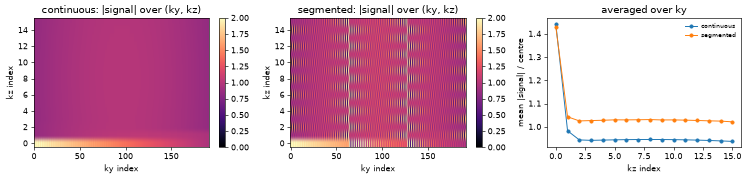

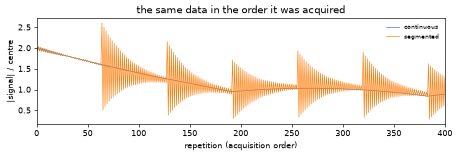

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.2))
for ax, (name, m) in zip(axes, (('continuous', mod_cont), ('segmented', mod_seg))):
    im = ax.imshow(m.T / flat, origin='lower', aspect='auto', cmap='magma', vmin=0, vmax=2.0)
    ax.set(title=f'{name}: |signal| over (ky, kz)', xlabel='ky index', ylabel='kz index')
    fig.colorbar(im, ax=ax, fraction=0.046)
axes[2].plot(mod_cont.mean(axis=0) / flat, 'o-', lw=1.2, ms=4, label='continuous')
axes[2].plot(mod_seg.mean(axis=0) / flat, 'o-', lw=1.2, ms=4, label='segmented')
axes[2].set(xlabel='kz index', ylabel='mean |signal| / centre', title='averaged over ky')
axes[2].legend(fontsize=7, frameon=False)
fig.tight_layout()

order = np.array(REP_TABLE)
fig, ax = plt.subplots(figsize=(8.0, 2.8))
ax.plot(np.abs(k_rep_cont[rep_echo][order[:, 0], order[:, 1]]) / flat, lw=0.8,
        label='continuous')
ax.plot(np.abs(k_rep_seg[rep_echo][order[:, 0], order[:, 1]]) / flat, lw=0.8, label='segmented')
ax.set(xlabel='repetition (acquisition order)', ylabel='|signal| / centre',
       title='the same data in the order it was acquired', xlim=(0, 400))
ax.legend(fontsize=8, frameon=False)
fig.tight_layout()

for name, m in (('continuous', mod_cont), ('segmented', mod_seg)):
    seq_order = np.abs(
        (k_rep_cont if name == 'continuous' else k_rep_seg)[rep_echo][order[:, 0], order[:, 1]])
    print(f'{name:12s} across the table {m.min() / flat:.2f} .. {m.max() / flat:.2f} of centre; '
          f'first view {seq_order[0] / flat:.2f}, last {seq_order[-1] / flat:.2f}')

              axis   off-peak   neighbours  further out  largest far
continuous       y      0.161        0.063        0.097       0.0086
segmented        y      1.128        0.063        1.064       0.0899


continuous       z      0.479        0.066        0.412       0.0342
segmented        z      0.358        0.047        0.311       0.0247


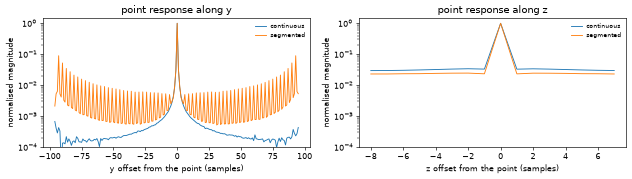

In [13]:
def point_profile(cube, axis):
    # The point object's own image along one axis, normalised to its peak.
    image = np.abs(np.fft.fftshift(np.fft.ifftn(np.fft.ifftshift(cube))))
    line = (image[REP_NX // 2, :, REP_NZ // 2] if axis == 'y'
            else image[REP_NX // 2, REP_NY // 2, :])
    return line / line.max()


fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.2))
print(f'{"":12s}{"axis":>6s}{"off-peak":>11s}{"neighbours":>13s}{"further out":>13s}'
      f'{"largest far":>13s}')
for ax, axis in zip(axes, ('y', 'z')):
    n = REP_NY if axis == 'y' else REP_NZ
    centre = n // 2
    for name, cube in (('continuous', k_rep_cont), ('segmented', k_rep_seg)):
        p = point_profile(cube, axis)
        ax.plot(np.arange(n) - centre, p, lw=1.1, label=name)
        far = np.array([p[i] for i in range(n) if abs(i - centre) > 1])
        print(f'{name:12s}{axis:>6s}{p.sum() - 1:11.3f}'
              f'{p[centre - 1] + p[centre + 1]:13.3f}{far.sum():13.3f}{far.max():13.4f}')
    ax.set(xlabel=f'{axis} offset from the point (samples)', ylabel='normalised magnitude',
           yscale='log', ylim=(1e-4, 1.5), title=f'point response along {axis}')
    ax.legend(fontsize=7, frameon=False)
fig.tight_layout()

### Reading that honestly

**The interruption costs on `ky`, not on `kz`.** That follows from where the shot boundaries fall:
each constant-`kz` line is 192 views and a shot is 64, so every line is cut into three, and the
cuts land at fixed `ky` positions. The partition axis barely notices.

The numbers to read are the last two columns. The **immediate neighbours** are unchanged between
the two acquisitions on both axes -- segmentation does not blur the point, so resolution is intact.
What changes is the energy **further out** along `y`, which grows by roughly a factor of seven, and
whose largest individual far sample grows by about ten. A step discontinuity in k-space spreads
signal broadly rather than into a single clean replica, which is what the profile shows: the
strongest off-peak samples sit near the edge of the `y` field of view rather than at one ghost
position.

Two cautions on these numbers. They are **summed normalised magnitudes over a sampled profile** --
not energy, and not a resolution metric; nothing stronger is claimed from them than the comparison
between two acquisitions measured the same way. And they belong to *this* protocol: a shot is 64
views against a white-matter time constant of about 83 repetitions, so each shot stays on its own
opening slope. Longer shots would let each settle and change both the size and the shape of the
effect, which is why `01` fixes the shot length rather than the shot count -- that ratio is the
quantity the result depends on, and it is the one the reduced protocol was built to preserve.

**This also corrects an earlier reading.** Measured on the reduced protocol and looking only at
`z`, segmentation appeared to be the *less* modulated of the two. That conclusion was an artifact
of a surrogate whose shot-to-transient ratio differed from the representative acquisition's, and of
looking at the axis the shot period does not divide.

reduced protocol, peak |difference| 1.18, 0.242 of the continuous peak


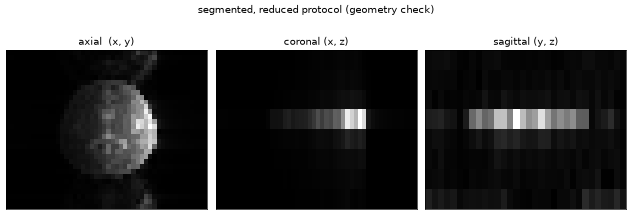

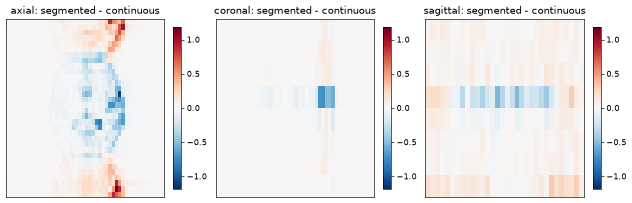

In [14]:
if BRAIN_IMAGES:
    rows_seg = simulate(SEQ_DIR / 'bssfp_3d_validation_segmented.seq', brain)
    k_seg, vol_seg = reconstruct(rows_seg)
    three_planes(np.abs(vol_seg), 'segmented, reduced protocol (geometry check)')
    a, b = np.abs(vol_cont), np.abs(vol_seg)
    diff = b - a
    scale = np.abs(diff).max()
    fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.6))
    for ax, (name, plane) in zip(axes, (('axial', diff[:, :, NZ // 2].T),
                                        ('coronal', diff[:, NY // 2, :].T),
                                        ('sagittal', diff[NX // 2, :, :].T))):
        im = ax.imshow(plane, cmap='RdBu_r', origin='lower', aspect='auto',
                       vmin=-scale, vmax=scale)
        ax.set(title=f'{name}: segmented - continuous', xticks=[], yticks=[])
        fig.colorbar(im, ax=ax, fraction=0.046)
    fig.tight_layout()
    print(f'reduced protocol, peak |difference| {scale:.4g}, '
          f'{scale / a.max():.3f} of the continuous peak')
else:
    print('BRAIN_IMAGES is off -- the representative point-object rows above are the result')

## 5. Does it behave like bSSFP?

Balanced gradients and a correct geometry would look the same for any 3D Cartesian acquisition. The
signature that says *balanced SSFP* is the off-resonance response: periodic with period `1/TR`, and
with nulls whose position depends on the RF phase increment. Under the `0/pi` cycle used here they
sit at `+-1/(2 TR)`, which is what puts the passband on resonance.

The sweep uses the **ramped** diagnostic train -- the shipped preparation -- and reads its tail.
That tail is usable because the train is 450 repetitions and white matter reaches 1% in about 380;
the spread of the tail itself is reported, so "settled" is measured rather than asserted.

deepest two samples at -119 and +119 Hz; 1/(2 TR) predicts -119 and +119 Hz
worst tail spread over the last 40 repetitions of any sweep point: 0.0095
passband ripple within +-20 Hz: 1.00x


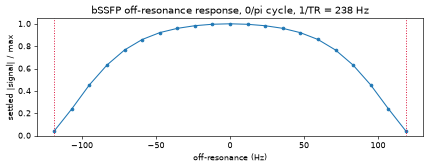

In [15]:
first_ramp, k_ramp = BUILT[f'{RAMP_STEPS}-step ramp']
sweep_hz = np.linspace(-NULL_HZ, NULL_HZ, 21)
response, spread = [], []
for df in sweep_hz:
    rows = simulate(DIAG_DIR / f'prep_ramp{RAMP_STEPS}.seq',
                    voxel(B0=float(df), **TISSUES['white matter']))
    s = np.abs(rows[first_ramp:, ECHO])
    response.append(s[-40:].mean())
    spread.append(s[-40:].std() / s[-40:].mean())
response, spread = np.array(response), np.array(spread)

fig, ax = plt.subplots(figsize=(7.5, 3.0))
ax.plot(sweep_hz, response / response.max(), 'o-', lw=1.3, ms=3.5)
for null in (-NULL_HZ, NULL_HZ):
    ax.axvline(null, color='crimson', ls=':', lw=1.2)
ax.set(xlabel='off-resonance (Hz)', ylabel='settled |signal| / max',
       title=f'bSSFP off-resonance response, 0/pi cycle, 1/TR = {1 / TR_S:.0f} Hz')
fig.tight_layout()

deepest = sweep_hz[np.argsort(response)[:2]]
print(f'deepest two samples at {deepest[0]:+.0f} and {deepest[1]:+.0f} Hz; '
      f'1/(2 TR) predicts {-NULL_HZ:+.0f} and {NULL_HZ:+.0f} Hz')
print(f'worst tail spread over the last 40 repetitions of any sweep point: {spread.max():.4f}')
print(f'passband ripple within +-20 Hz: '
      f'{response[np.abs(sweep_hz) < 20].max() / response[np.abs(sweep_hz) < 20].min():.2f}x')

## 6. What remains a protocol choice

Everything above follows from decisions that live **above** the repetition. None has been shown
optimal -- only what each does on this protocol.

```text
preparation       a 24-step flip ramp.  It beats alpha/2 - TR/2 across the band and ties it on
                  resonance and under B1 error.  It does not change the decay rate; nothing can.

shot length       64 views between interruptions.  This is the quantity the segmentation result
                  depends on, through its ratio to the transient time constant, which is why it
                  is fixed rather than derived from a segment count.

view order        bidirectional sequential, so no repetition inside a shot moves more than one
                  encoding step.  A contrast-prepared protocol would additionally rotate each
                  line's start so central views land at a chosen moment.

recovery          107 ms between shots, following the interval reported for a clinical 3D
                  segmented trueFISP breath-hold.

phase increment   180 degrees, which places the passband on resonance.
```

**Limitations.** One phantom, one field strength, no B1 map, no motion. The off-resonance sweep is
a single voxel, so it shows the response and not what banding does to an image. The volume
reconstruction uses the reduced protocol; the transient, ordering and segmentation measurements use
the representative files directly.

## Summary

- The transient's **rate** is an eigenvalue of the repetition's transfer matrix, computed rather
  than inferred from a finite run. A preparation changes the initial error, not the rate.
- Preparation was chosen by measuring across the off-resonance band, not only on resonance.
  `alpha/2 - TR/2` and a flip ramp tie at the passband centre and under `+-10%` B1; the ramp is
  better toward the band edge. Its length was chosen from a measured sweep, shown here.
- CSF is excluded from settling claims: its eigenvalue implies roughly 2500 repetitions to 5%.
- The segmentation measurement is made on the **representative** acquisition, because the quantity
  it depends on is the ratio of shot length to transient time constant -- matching TR alone would
  not have preserved it.
- The reduced protocol is used for geometry: the continuous volume reconstructs correctly in all
  three planes, with the three matrix dimensions distinct enough that a swap would change its shape.
- The off-resonance response is periodic with nulls at `+-1/(2 TR)` under the `0/pi` cycle, with the
  tail's own spread reported.

## References

- Bieri O, Scheffler K. *Fundamentals of balanced steady state free precession MRI.*
  J Magn Reson Imaging 2013;38:2-11.
- Bernstein MA, King KF, Zhou XJ. *Handbook of MRI Pulse Sequences.* Elsevier, 2004, Section 14.1.
- Hargreaves BA, Vasanawala SS, Pauly JM, Nishimura DG. *Characterization and reduction of the
  transient response in steady-state MR imaging.* Magn Reson Med 2001;46:149-158.
- Le Roux P. *Simplified model and stabilization of SSFP sequences.* J Magn Reson 2003;163:23-37.
- Morita S, Saito N, Suzuki K, et al. *Contrast changes in portal vein and bile duct between
  centric and linear k-space ordering on three-dimensional segmented true FISP MRI.*
  Magn Reson Imaging 2008;26:1244-1249.
- Spincemaille P, Nguyen TD, Wang Y. *View ordering for magnetization prepared steady state free
  precession acquisition.* Magn Reson Med 2004;52:461-466.
- Scheffler K. *On the transient phase of balanced SSFP sequences.* Magn Reson Med 2003;49:781-783.